# Nigerian Commodity Price Volatility — Regime-Aware Elastic Net Model

**Objective:** Forecast annualized realized volatility corresponding to Maize, Rice, PMS, and Diesel prices.

## Pipeline Stages
1. **Load Data:** Imports `master_dataset.csv` from Data Engineering phase.
2. **Dimensionality Reduction (PCA):** Compresses highly correlated macro features into orthogonal principal components.
3. **Feature Engineering:** Instantiates $t-1, t-2, t-3$ lagged features and the `Regime_High_Vol` indicator.
4. **Modeling (Elastic Net):** Trains regression with L1/L2 penalties.
5. **Evaluation:** R², RMSE, and Variable Importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

print('Libraries imported.')

Libraries imported.


In [2]:
#
import os
import shutil

try:
    from google.colab import drive
    drive.mount("/content/drive")
    print(" Drive mounted successfully.")

    if not os.path.exists("output"):
        os.makedirs("output")

    !cp "/content/drive/MyDrive/master_dataset.csv" output/
    if os.path.exists("output/master_dataset.csv"):
        print(" Successfully loaded master_dataset.csv from Google Drive!")
    else:
        print(" Copy failed. Does master_dataset.csv exist in the root of your Google Drive?")

except ImportError:
    print("ℹNot running in Google Colab, skipping drive mount.")
except Exception as e:
    print(f" Error: {e}")


Mounted at /content/drive
 Drive mounted successfully.
 Successfully loaded master_dataset.csv from Google Drive!


---
## 1. Load Data
Assumes `master_dataset.csv` is correctly prepared in the `output/` folder.

In [3]:
import os

# Ensure you are referencing the file created in the datapreparation notebook
file_path = 'output/master_dataset.csv'


In [4]:
df = pd.read_csv(file_path, parse_dates=[0], index_col=0)

In [5]:
df.head(10)

,Brent_Crude_USD,US_10Y_Yield,PMS_Price,Diesel_Price,Maize_Price,Rice_Price,Official_FX,Parallel_FX,CPI_YoY,Food_CPI_YoY,CPI_Monthly,FX_Premium,M2_NGN,PMS_LogReturn,PMS_RealVol,Diesel_LogReturn,Diesel_RealVol,Maize_LogReturn,Maize_RealVol,Rice_LogReturn,Rice_RealVol
2018-01-01,68.889130,2.58,197.400,211.00,4187.117603,6746.619718,305.78,363.20,15.13,18.92,16.22,0.187782,23963031.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,65.696500,2.86,192.375,212.00,4045.684358,375.000000,305.90,362.48,14.33,17.59,15.93,0.184962,24143010.28,-0.025786,NaN,0.004728,NaN,-0.034362,NaN,-2.889871,NaN
2018-03-01,66.891818,2.84,161.875,211.00,3947.974860,410.714286,305.74,362.07,13.34,16.08,15.60,0.184242,24424422.14,-0.172622,NaN,-0.004728,NaN,-0.024448,NaN,0.090972,NaN
2018-04-01,71.932857,2.87,146.000,210.45,4425.265363,392.857143,305.61,362.25,12.48,14.80,15.20,0.185334,24474153.99,-0.103218,NaN,-0.002610,NaN,0.114127,NaN,-0.044452,NaN
2018-05-01,76.934348,2.98,145.000,210.00,4276.641100,392.857143,305.83,362.86,11.61,13.45,14.79,0.186476,25169014.19,-0.006873,NaN,-0.002141,NaN,-0.034162,NaN,0.000000,NaN
2018-06-01,75.802857,2.91,145.000,212.50,4283.685000,374.647500,305.87,360.66,11.23,12.98,14.37,0.179128,24814004.52,0.000000,NaN,0.011834,NaN,0.001646,NaN,-0.047460,NaN
2018-07-01,75.229091,2.89,144.900,220.00,3937.276667,392.857143,305.81,359.36,11.14,12.85,13.95,0.175109,24971101.93,-0.000690,NaN,0.034686,NaN,-0.084324,NaN,0.047460,NaN
2018-08-01,73.851304,2.89,144.680,221.00,3967.528000,6796.714000,306.06,359.00,11.23,13.16,13.55,0.172973,24859346.47,-0.001519,NaN,0.004535,NaN,0.007654,NaN,2.850748,NaN
2018-09-01,79.163000,3.00,144.400,223.75,3529.266000,419.642500,306.27,362.86,11.28,13.31,13.16,0.184772,25560662.33,-0.001937,NaN,0.012367,NaN,-0.117053,NaN,-2.784791,NaN
2018-10-01,80.783478,3.15,143.920,229.80,3141.873400,407.142000,306.50,360.74,11.26,13.28,12.78,0.176966,26041903.87,-0.003330,NaN,0.026680,NaN,-0.116271,NaN,-0.030241,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 96 entries, 2018-01-01 to 2025-12-01
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brent_Crude_USD   96 non-null     float64
 1   US_10Y_Yield      96 non-null     float64
 2   PMS_Price         96 non-null     float64
 3   Diesel_Price      96 non-null     float64
 4   Maize_Price       96 non-null     float64
 5   Rice_Price        96 non-null     float64
 6   Official_FX       96 non-null     float64
 7   Parallel_FX       96 non-null     float64
 8   CPI_YoY           96 non-null     float64
 9   Food_CPI_YoY      96 non-null     float64
 10  CPI_Monthly       96 non-null     float64
 11  FX_Premium        96 non-null     float64
 12  M2_NGN            96 non-null     float64
 13  PMS_LogReturn     95 non-null     float64
 14  PMS_RealVol       84 non-null     float64
 15  Diesel_LogReturn  95 non-null     float64
 16  Diesel_RealVol    84 non-n

In [7]:
df.isna().sum()

,0
Brent_Crude_USD,0
US_10Y_Yield,0
PMS_Price,0
Diesel_Price,0
Maize_Price,0
Rice_Price,0
Official_FX,0
Parallel_FX,0
CPI_YoY,0
Food_CPI_YoY,0


In [8]:
df.columns

Index(['Brent_Crude_USD', 'US_10Y_Yield', 'PMS_Price', 'Diesel_Price',
       'Maize_Price', 'Rice_Price', 'Official_FX', 'Parallel_FX', 'CPI_YoY',
       'Food_CPI_YoY', 'CPI_Monthly', 'FX_Premium', 'M2_NGN', 'PMS_LogReturn',
       'PMS_RealVol', 'Diesel_LogReturn', 'Diesel_RealVol', 'Maize_LogReturn',
       'Maize_RealVol', 'Rice_LogReturn', 'Rice_RealVol'],
      dtype='object')

In [9]:
df.rename(columns={"Unnamed: 0":"Date"}, inplace=True)

In [10]:
df.columns

Index(['Brent_Crude_USD', 'US_10Y_Yield', 'PMS_Price', 'Diesel_Price',
       'Maize_Price', 'Rice_Price', 'Official_FX', 'Parallel_FX', 'CPI_YoY',
       'Food_CPI_YoY', 'CPI_Monthly', 'FX_Premium', 'M2_NGN', 'PMS_LogReturn',
       'PMS_RealVol', 'Diesel_LogReturn', 'Diesel_RealVol', 'Maize_LogReturn',
       'Maize_RealVol', 'Rice_LogReturn', 'Rice_RealVol'],
      dtype='object')

In [11]:
if "Date" in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])



In [12]:
df.describe()

,Brent_Crude_USD,US_10Y_Yield,PMS_Price,Diesel_Price,Maize_Price,Rice_Price,Official_FX,Parallel_FX,CPI_YoY,Food_CPI_YoY,CPI_Monthly,FX_Premium,M2_NGN,PMS_LogReturn,PMS_RealVol,Diesel_LogReturn,Diesel_RealVol,Maize_LogReturn,Maize_RealVol,Rice_LogReturn,Rice_RealVol
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,9.600000e+01,95.000000,84.000000,95.000000,84.000000,94.000000,83.000000,95.000000,84.000000
mean,72.441328,2.850000,388.515663,632.475050,17734.774282,2860.698078,-6102.961398,-17473.757444,-211.896275,-73.104557,19.908281,0.647370,5.726631e+07,0.018098,0.287429,0.015762,0.192636,0.011630,2.492445,0.013596,2.150195
std,16.647094,1.258207,330.181466,446.934680,33724.664890,5118.764658,10721.283331,29930.278138,874.396409,349.879581,8.734764,0.572859,3.334461e+07,0.105403,0.239977,0.070864,0.129188,0.888619,2.154269,0.818124,1.718739
min,26.848636,0.620000,124.650000,192.666667,-90535.183574,364.512000,-40740.597966,-114561.920275,-5526.851676,-2150.279620,11.270000,0.153874,2.396303e+07,-0.198494,0.005704,-0.153777,0.016661,-3.459671,0.192993,-2.889871,0.071565
25%,64.064872,1.685000,145.000000,230.000000,3523.799500,605.406250,-8191.684028,-23047.453132,11.355000,13.510000,12.750000,0.184915,2.904508e+07,-0.005594,0.110997,-0.015102,0.083547,-0.043789,0.539080,-0.006969,0.263534
50%,73.368149,2.900000,184.312500,349.000000,7962.052088,765.132500,120.294590,-155.127513,15.420000,17.375000,16.665000,0.377378,4.459120e+07,0.000903,0.242098,0.004357,0.161747,0.007778,1.063766,0.022989,2.567387
75%,81.893377,4.067500,683.037500,1112.200000,17554.856250,2144.702500,306.950000,362.307500,21.372500,23.845000,24.832500,0.969882,8.210968e+07,0.033050,0.372083,0.028455,0.307527,0.127601,4.905681,0.100496,3.727463
max,117.692727,4.800000,1175.333669,1531.250000,150195.353927,24549.533053,381.000000,481.600000,34.600000,40.870000,41.111195,2.152581,1.244002e+08,0.738698,0.801378,0.412845,0.430486,3.281439,5.945385,2.850748,5.072143


## EXPLORATORY DATA ANALYSIS

In [13]:
sns.set_theme(style="whitegrid", context="talk")

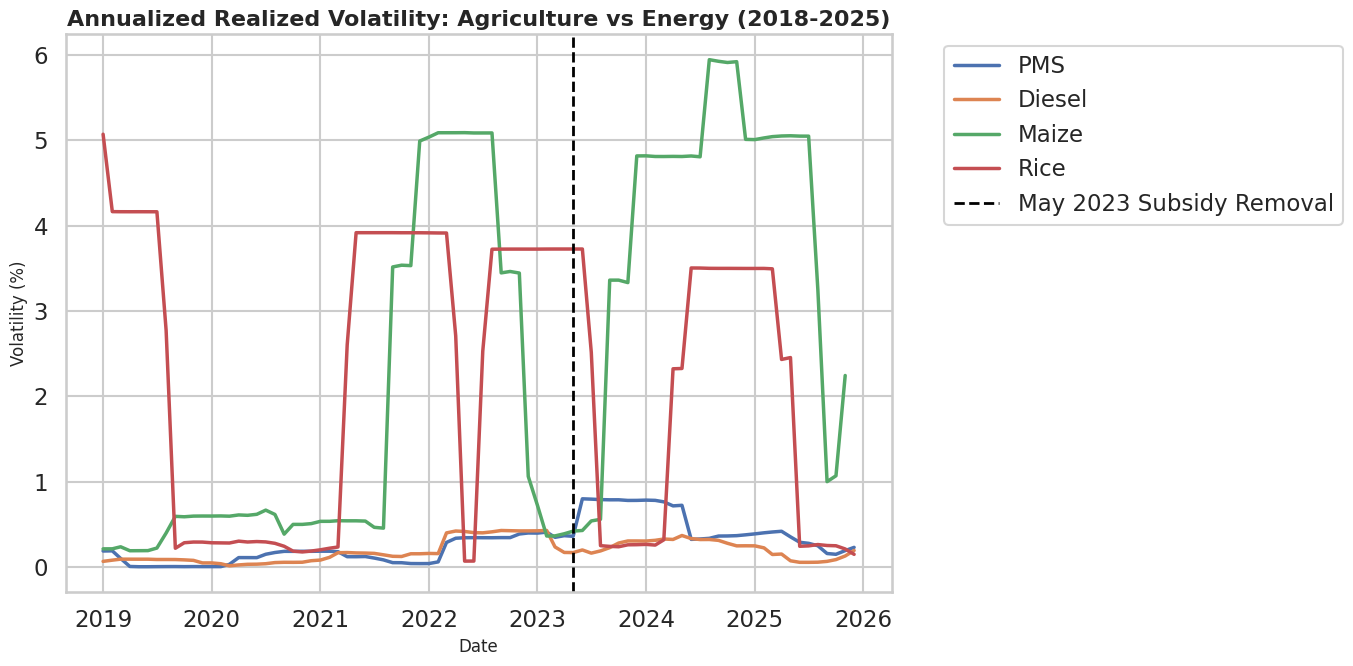

In [14]:
# 1. Commodity Volatility Over Time
vol_cols = [c for c in df.columns if c.endswith('_RealVol')]
if vol_cols:
    plt.figure(figsize=(14, 7))
    for col in vol_cols:
        commodity_name = col.replace('_RealVol', '')
        plt.plot(df.index, df[col], label=commodity_name, linewidth=2.5)

    plt.title('Annualized Realized Volatility: Agriculture vs Energy (2018-2025)', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility (%)', fontsize=12)
    plt.xlabel('Date', fontsize=12)

    # Highlight the May 2023 Subsidy Removal
    if pd.to_datetime('2023-05-01') in df.index:
        plt.axvline(pd.to_datetime('2023-05-01'), color='black', linestyle='--', linewidth=2, label='May 2023 Subsidy Removal')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Could not find any volatility columns ending in '_RealVol'")


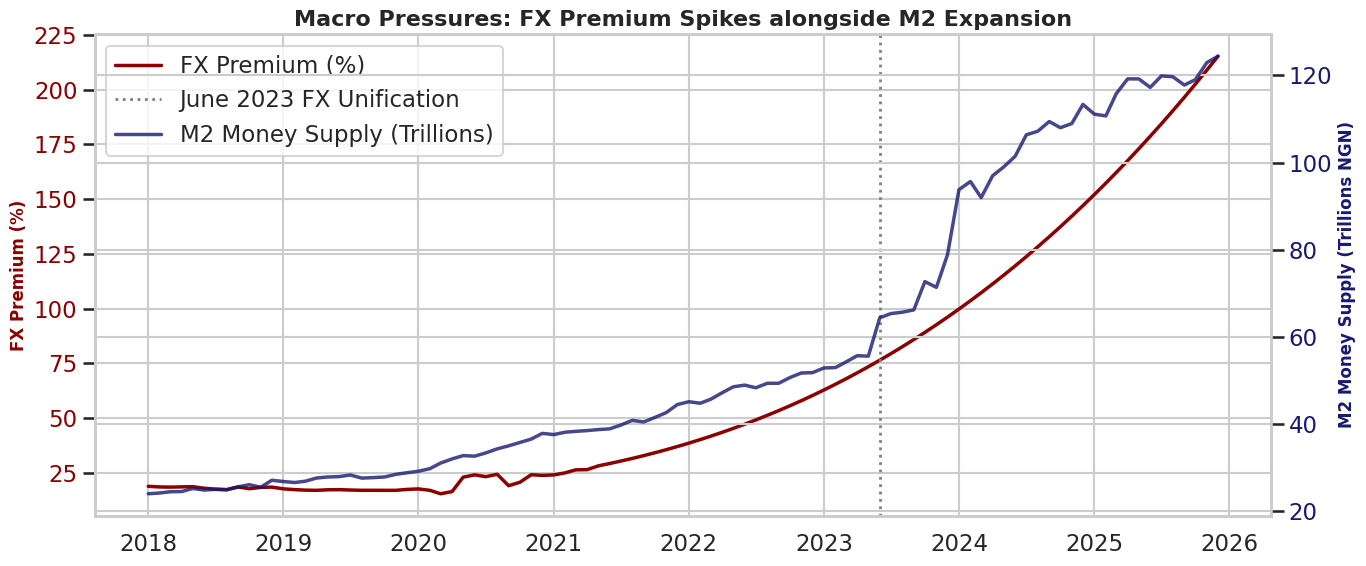

In [15]:
# 2. Key Macro Drivers: FX Premium vs M2 Money Supply
if 'FX_Premium' in df.columns and 'M2_NGN' in df.columns:
    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.set_title('Macro Pressures: FX Premium Spikes alongside M2 Expansion', fontsize=16, fontweight='bold')

    color1 = 'darkred'
    ax1.plot(df.index, df['FX_Premium'] * 100, color=color1, linewidth=2.5, label='FX Premium (%)')
    ax1.set_ylabel('FX Premium (%)', color=color1, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    color2 = 'midnightblue'
    ax2.plot(df.index, df['M2_NGN'] / 1_000_000, color=color2, linewidth=2.5, alpha=0.8, label='M2 Money Supply (Trillions)')
    ax2.set_ylabel('M2 Money Supply (Trillions NGN)', color=color2, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Highlight June 2023 FX Unification
    if pd.to_datetime('2023-06-01') in df.index:
        ax1.axvline(pd.to_datetime('2023-06-01'), color='gray', linestyle=':', linewidth=2, label='June 2023 FX Unification')

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    fig.tight_layout()
    plt.show()
else:
    print("FX_Premium or M2_NGN columns are missing from the dataframe")


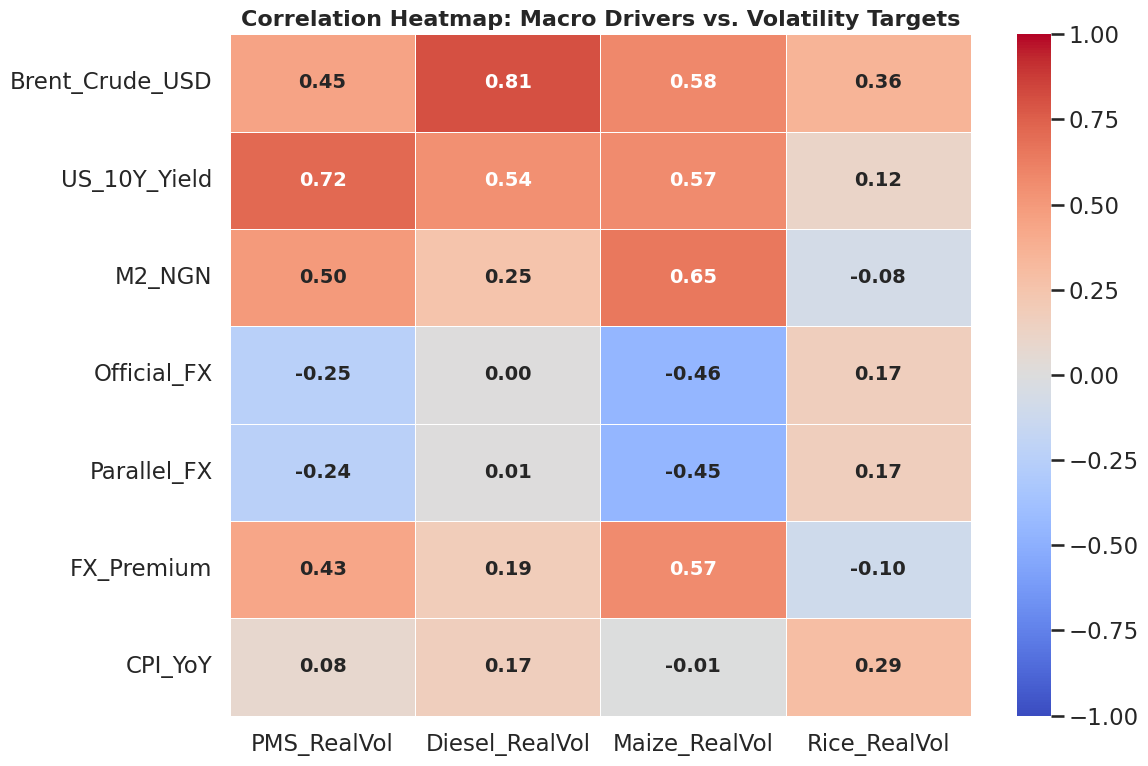

In [16]:
# 3. Correlation Heatmap: Macro vs Volatility
macro_cols = ['Brent_Crude_USD', 'US_10Y_Yield', 'M2_NGN', 'Official_FX', 'Parallel_FX', 'FX_Premium', 'CPI_YoY']
existing_macro = [c for c in macro_cols if c in df.columns]

if existing_macro and vol_cols:
    plt.figure(figsize=(12, 8))

    corr_matrix = df[existing_macro + vol_cols].corr()
    focus_corr = corr_matrix.loc[existing_macro, vol_cols]

    sns.heatmap(focus_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
                annot_kws={'size': 14, 'weight': 'bold'}, linewidths=.5)

    plt.title('Correlation Heatmap: Macro Drivers vs. Volatility Targets', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Missing columns required for the correlation heatmap")


## A LITTLE MATHS

In [17]:
df.describe()

,Brent_Crude_USD,US_10Y_Yield,PMS_Price,Diesel_Price,Maize_Price,Rice_Price,Official_FX,Parallel_FX,CPI_YoY,Food_CPI_YoY,CPI_Monthly,FX_Premium,M2_NGN,PMS_LogReturn,PMS_RealVol,Diesel_LogReturn,Diesel_RealVol,Maize_LogReturn,Maize_RealVol,Rice_LogReturn,Rice_RealVol
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,9.600000e+01,95.000000,84.000000,95.000000,84.000000,94.000000,83.000000,95.000000,84.000000
mean,72.441328,2.850000,388.515663,632.475050,17734.774282,2860.698078,-6102.961398,-17473.757444,-211.896275,-73.104557,19.908281,0.647370,5.726631e+07,0.018098,0.287429,0.015762,0.192636,0.011630,2.492445,0.013596,2.150195
std,16.647094,1.258207,330.181466,446.934680,33724.664890,5118.764658,10721.283331,29930.278138,874.396409,349.879581,8.734764,0.572859,3.334461e+07,0.105403,0.239977,0.070864,0.129188,0.888619,2.154269,0.818124,1.718739
min,26.848636,0.620000,124.650000,192.666667,-90535.183574,364.512000,-40740.597966,-114561.920275,-5526.851676,-2150.279620,11.270000,0.153874,2.396303e+07,-0.198494,0.005704,-0.153777,0.016661,-3.459671,0.192993,-2.889871,0.071565
25%,64.064872,1.685000,145.000000,230.000000,3523.799500,605.406250,-8191.684028,-23047.453132,11.355000,13.510000,12.750000,0.184915,2.904508e+07,-0.005594,0.110997,-0.015102,0.083547,-0.043789,0.539080,-0.006969,0.263534
50%,73.368149,2.900000,184.312500,349.000000,7962.052088,765.132500,120.294590,-155.127513,15.420000,17.375000,16.665000,0.377378,4.459120e+07,0.000903,0.242098,0.004357,0.161747,0.007778,1.063766,0.022989,2.567387
75%,81.893377,4.067500,683.037500,1112.200000,17554.856250,2144.702500,306.950000,362.307500,21.372500,23.845000,24.832500,0.969882,8.210968e+07,0.033050,0.372083,0.028455,0.307527,0.127601,4.905681,0.100496,3.727463
max,117.692727,4.800000,1175.333669,1531.250000,150195.353927,24549.533053,381.000000,481.600000,34.600000,40.870000,41.111195,2.152581,1.244002e+08,0.738698,0.801378,0.412845,0.430486,3.281439,5.945385,2.850748,5.072143


In [18]:
import numpy as np

# 1. Fix the Spline Overshoot (Remove Negatives)
# Identify columns that physically cannot be negative (prices, rates, M2)
non_negative_cols = [
    'PMS_Price', 'Diesel_Price', 'Maize_Price', 'Rice_Price',
    'Official_FX', 'Parallel_FX', 'M2_NGN'
]

# Wipe negative anomalies to NaN
for col in non_negative_cols:
    if col in df.columns:
        df.loc[df[col] <= 0, col] = np.nan

# Re-impute safely using Linear interpolation (guarantees no overshoot between positive points)
# We fill forward/backward just in case the anomaly was at the very start/end dates
df = df.interpolate(method='linear', limit_direction='both')


# 2. Logarithmic Transformations (Squashing Exponential Growth)
log_cols = ['M2_NGN', 'Official_FX', 'Parallel_FX', 'Maize_Price', 'Rice_Price', 'PMS_Price', 'Diesel_Price']

for col in log_cols:
    if col in df.columns:
        # Create new log-transformed columns
        df[f'Log_{col}'] = np.log(df[col])

print(" Interpolation artifacts scrubbed!")
print(" Log Transformations applied!")

# Let's check the describe table again to prove the negatives are gone
display(df[non_negative_cols].describe())


 Interpolation artifacts scrubbed!
 Log Transformations applied!


,PMS_Price,Diesel_Price,Maize_Price,Rice_Price,Official_FX,Parallel_FX,M2_NGN
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,9.600000e+01
mean,388.515663,632.475050,18807.988955,2860.698078,203.615721,236.703439,5.726631e+07
std,330.181466,446.934680,31828.992616,5118.764658,125.185003,155.071940,3.334461e+07
min,124.650000,192.666667,314.089800,364.512000,83.023389,93.518807,2.396303e+07
25%,145.000000,230.000000,3640.672125,605.406250,83.023389,93.518807,2.904508e+07
50%,184.312500,349.000000,8048.904062,765.132500,120.294590,93.518807,4.459120e+07
75%,683.037500,1112.200000,17554.856250,2144.702500,306.950000,362.307500,8.210968e+07
max,1175.333669,1531.250000,150195.353927,24549.533053,381.000000,481.600000,1.244002e+08


## PCA(PRINCIPAL COMPONENT ANALYSIS)

In [19]:

#  Define our specific macroeconomic drivers (we drop the targets)
# Notice we are using the new 'Log_' versions for the exponential variables!
macro_vars = [
    'Brent_Crude_USD', 'US_10Y_Yield', 'Log_M2_NGN',
    'Log_Official_FX', 'Log_Parallel_FX', 'FX_Premium',
    'CPI_YoY', 'Food_CPI_YoY'
]

available_macro = [c for c in macro_vars if c in df.columns]

# Create a clean dataframe just for modeling features
df_features = df.copy()



In [20]:
# Standardize the Macro Variables (mean=0, std=1)
scaler = StandardScaler()
scaled_macro = scaler.fit_transform(df_features[available_macro])



In [21]:
# 3. Fit Principal Component Analysis (PCA)
# We will compress the 8 macro variables into exactly 3 robust "Factors"
n_components = 3
pca = PCA(n_components=n_components)
pca_features = pca.fit_transform(scaled_macro)

print('=== PCA EXPLAINED VARIANCE ===')
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'Principal Component {i+1}: {ratio*100:.2f}% of total macro information')
print(f'Total Information Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%\\n')


=== PCA EXPLAINED VARIANCE ===
Principal Component 1: 61.83% of total macro information
Principal Component 2: 25.39% of total macro information
Principal Component 3: 7.53% of total macro information
Total Information Retained: 94.75%\n


In [22]:
# Attach the new compressed Factors back to our dataframe
for i in range(n_components):
    df_features[f'Macro_PC{i+1}'] = pca_features[:, i]
print(f" Added {n_components} orthogonal Principal Components to the dataset!")
display(df_features[[f'Macro_PC{i+1}' for i in range(n_components)]].head())

 Added 3 orthogonal Principal Components to the dataset!


,Macro_PC1,Macro_PC2,Macro_PC3
2018-01-01,-1.900764,-0.102882,0.470039
2018-02-01,-1.850774,-0.159110,0.321171
2018-03-01,-1.830614,-0.130448,0.364946
2018-04-01,-1.751265,0.013426,0.571210
2018-05-01,-1.629364,0.164654,0.751505


## feature engineering

In [23]:
# Create Lagged Features for our Principal Components (t-1, t-2, t-3)
pca_cols = [f'Macro_PC{i+1}' for i in range(n_components)]
lags = [1, 2, 3]

for col in pca_cols:
    for lag in lags:
        df_features[f'{col}_lag{lag}'] = df_features[col].shift(lag)

print("Lagged features created for all Principal Components.")


Lagged features created for all Principal Components.


In [24]:
# Define the High Volatility Regime based on FX Premium variance
if 'FX_Premium' in df_features.columns:
    fx_roll_var = df_features['FX_Premium'].rolling(3).var()

    # Calculate the 75th percentile (top 25% highest variance periods)
    crisis_threshold = fx_roll_var.quantile(0.75)

    # Assign 1 if in high vol regime, 0 otherwise
    df_features['Regime_High_Vol'] = (fx_roll_var > crisis_threshold).astype(int)

    print("Defined 'Regime_High_Vol' based on top 25% FX Premium variance.")
    print(f"Number of months in High Volatility Regime: {df_features['Regime_High_Vol'].sum()} out of {len(df_features)}")
else:
    print("Error: FX_Premium not found. Cannot define the regime indicator.")


Defined 'Regime_High_Vol' based on top 25% FX Premium variance.
Number of months in High Volatility Regime: 24 out of 96


In [25]:
# Drop rows with NaNs caused by the lagging process (first 3 months)
df_features = df_features.dropna(subset=[f'Macro_PC1_lag3'])

print(f"Final Feature Engineering Shape: {df_features.shape}")


Final Feature Engineering Shape: (93, 41)


In [26]:
df_features.head()

,Brent_Crude_USD,US_10Y_Yield,PMS_Price,Diesel_Price,Maize_Price,Rice_Price,Official_FX,Parallel_FX,CPI_YoY,Food_CPI_YoY,CPI_Monthly,FX_Premium,M2_NGN,PMS_LogReturn,PMS_RealVol,Diesel_LogReturn,Diesel_RealVol,Maize_LogReturn,Maize_RealVol,Rice_LogReturn,Rice_RealVol,Log_M2_NGN,Log_Official_FX,Log_Parallel_FX,Log_Maize_Price,Log_Rice_Price,Log_PMS_Price,Log_Diesel_Price,Macro_PC1,Macro_PC2,Macro_PC3,Macro_PC1_lag1,Macro_PC1_lag2,Macro_PC1_lag3,Macro_PC2_lag1,Macro_PC2_lag2,Macro_PC2_lag3,Macro_PC3_lag1,Macro_PC3_lag2,Macro_PC3_lag3,Regime_High_Vol
2018-04-01,71.932857,2.87,146.00,210.45,4425.265363,392.857143,305.61,362.25,12.48,14.80,15.20,0.185334,24474153.99,-0.103218,0.189987,-0.002610,0.068581,0.114127,0.215025,-0.044452,5.072143,17.013128,5.722310,5.892335,8.395086,5.973446,4.983607,5.349248,-1.751265,0.013426,0.571210,-1.830614,-1.850774,-1.900764,-0.130448,-0.159110,-0.102882,0.364946,0.321171,0.470039,0
2018-05-01,76.934348,2.98,145.00,210.00,4276.641100,392.857143,305.83,362.86,11.61,13.45,14.79,0.186476,25169014.19,-0.006873,0.189987,-0.002141,0.068581,-0.034162,0.215025,0.000000,5.072143,17.041124,5.723029,5.894017,8.360923,5.973446,4.976734,5.347108,-1.629364,0.164654,0.751505,-1.751265,-1.830614,-1.850774,0.013426,-0.130448,-0.159110,0.571210,0.364946,0.321171,0
2018-06-01,75.802857,2.91,145.00,212.50,4283.685000,374.647500,305.87,360.66,11.23,12.98,14.37,0.179128,24814004.52,0.000000,0.189987,0.011834,0.068581,0.001646,0.215025,-0.047460,5.072143,17.026919,5.723160,5.887936,8.362569,5.925986,4.976734,5.358942,-1.678230,0.127207,0.724474,-1.629364,-1.751265,-1.830614,0.164654,0.013426,-0.130448,0.751505,0.571210,0.364946,0
2018-07-01,75.229091,2.89,144.90,220.00,3937.276667,392.857143,305.81,359.36,11.14,12.85,13.95,0.175109,24971101.93,-0.000690,0.189987,0.034686,0.068581,-0.084324,0.215025,0.047460,5.072143,17.033230,5.722964,5.884325,8.278245,5.973446,4.976044,5.393628,-1.687862,0.110327,0.699499,-1.678230,-1.629364,-1.751265,0.127207,0.164654,0.013426,0.724474,0.751505,0.571210,0
2018-08-01,73.851304,2.89,144.68,221.00,3967.528000,6796.714000,306.06,359.00,11.23,13.16,13.55,0.172973,24859346.47,-0.001519,0.189987,0.004535,0.068581,0.007654,0.215025,2.850748,5.072143,17.028744,5.723781,5.883322,8.285899,8.824195,4.974524,5.398163,-1.711190,0.072640,0.646947,-1.687862,-1.678230,-1.629364,0.110327,0.127207,0.164654,0.699499,0.724474,0.751505,0


In [27]:
!pip install mlflow -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 13.5 MB/s eta 0:00:00


In [28]:
import mlflow

In [29]:
# 1. DEFINE TARGET & PREDICTORS
# Change this variable to predict a different commodity (e.g., 'PMS_RealVol')
TARGET = 'Maize_RealVol'
if TARGET not in df_features.columns:
    print(f"Error: Target '{TARGET}' not found.")
else:
    # Predictor variables: the 3 Lags of the 3 Principal Components + The Regime Indicator
    pca_cols = [c for c in df_features.columns if 'Macro_PC' in c and '_lag' in c]
    regime_col = ['Regime_High_Vol'] if 'Regime_High_Vol' in df_features.columns else []

    predictors = pca_cols + regime_col

    # Drop NAs so the model doesn't crash
    model_data = df_features.dropna(subset=[TARGET] + predictors)

    X = model_data[predictors]
    y = model_data[TARGET]

    # 2. CHRONOLOGICAL TRAIN-TEST SPLIT (80/20)
    split_idx = int(len(X) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"Training Set: {len(X_train)} months (ends {X_train.index.max().strftime('%Y-%m')})")
    print(f"Testing Set:  {len(X_test)} months (starts {X_test.index.min().strftime('%Y-%m')})")

Training Set: 74 months (ends 2024-05)
Testing Set:  19 months (starts 2024-06)


## Elastic Net Training & MLflow Tracking

In [30]:
#  MLOPS: MLFLOW TRACKING & ELASTIC NET GRID SEARCH
if TARGET in df_features.columns:
    mlflow.set_experiment("Commodity_Volatility_Forecasting")

    with mlflow.start_run(run_name=f"ElasticNet_{TARGET}") as active_run:
        print(f"Training Regime-Aware Elastic Net for {TARGET}...")

        # Test L1 ratios (1 = Pure Lasso, 0 = Pure Ridge)
        l1_grid = [.1, .3, .5, .7, .9, .95, .99, 1]

        # Cross-validation engine automatically finds the best Alpha penalty
        regr = ElasticNetCV(cv=5, l1_ratio=l1_grid, random_state=42)
        regr.fit(X_train, y_train)

        # Make Forecasts on the unseen 20% test data
        preds = regr.predict(X_test)

        # Calculate Diagnostics
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        # --- LOG EVERYTHING TO MLFLOW ---
        mlflow.set_tag("Target_Commodity", TARGET)
        mlflow.set_tag("Model_Type", "ElasticNetCV")

        mlflow.log_param("Optimal_Alpha", regr.alpha_)
        mlflow.log_param("Optimal_L1_Ratio", regr.l1_ratio_)
        mlflow.log_param("Features_Used", len(predictors))

        mlflow.log_metric("Test_RMSE", rmse)
        mlflow.log_metric("Test_MAE", mae)
        mlflow.log_metric("Test_R2", r2)

        mlflow.sklearn.log_model(regr, "elastic_net_model")

        print("Training Complete and Logged to MLflow.")
        print(f"Optimal Penalty (Alpha): {regr.alpha_:.4f}")
        print(f"Optimal Mix (L1 Ratio):  {regr.l1_ratio_}")


2026/03/13 18:09:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/13 18:09:45 INFO mlflow.store.db.utils: Updating database tables
2026/03/13 18:09:47 INFO mlflow.tracking.fluent: Experiment with name 'Commodity_Volatility_Forecasting' does not exist. Creating a new experiment.


Training Regime-Aware Elastic Net for Maize_RealVol...


2026/03/13 18:09:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 18:09:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Complete and Logged to MLflow.
Optimal Penalty (Alpha): 0.0061
Optimal Mix (L1 Ratio):  1.0


In [31]:
#  PRINT PERFORMANCE
if TARGET in df_features.columns:
    print(f" OUT-OF-SAMPLE TEST PERFORMANCE FOR {TARGET}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R-Squared: {r2:.4f}")


 OUT-OF-SAMPLE TEST PERFORMANCE FOR Maize_RealVol
RMSE: 2.8276
MAE:  1.9022
R-Squared: -2.2925


## elastic net failed so we try random forest

In [32]:
from sklearn.ensemble import RandomForestRegressor

# MLOPS: TRACKING A RANDOM FOREST
if TARGET in df_features.columns:

    with mlflow.start_run(run_name=f"RandomForest_{TARGET}"):
        print(f"Training Non-Linear Random Forest for {TARGET}...")

        # Initialize a Random Forest with 200 decision trees
        rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
        rf.fit(X_train, y_train)

        # Make Forecasts on the unseen 20% test data
        preds_rf = rf.predict(X_test)

        # Calculate Diagnostics
        rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
        mae_rf = mean_absolute_error(y_test, preds_rf)
        r2_rf = r2_score(y_test, preds_rf)

        # --- LOG EVERYTHING TO MLFLOW ---
        mlflow.set_tag("Target_Commodity", TARGET)
        mlflow.set_tag("Model_Type", "RandomForest")

        mlflow.log_param("n_estimators", 200)
        mlflow.log_param("max_depth", 10)
        mlflow.log_param("Features_Used", len(predictors))

        mlflow.log_metric("Test_RMSE", rmse_rf)
        mlflow.log_metric("Test_MAE", mae_rf)
        mlflow.log_metric("Test_R2", r2_rf)

        mlflow.sklearn.log_model(rf, "random_forest_model")

        print("Training Complete and Logged to MLflow.")

        print(f"--- OUT-OF-SAMPLE TEST PERFORMANCE FOR {TARGET} ---")
        print(f"RMSE: {rmse_rf:.4f}")
        print(f"MAE:  {mae_rf:.4f}")
        print(f"R-Squared: {r2_rf:.4f}")


Training Non-Linear Random Forest for Maize_RealVol...


2026/03/13 18:09:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 18:09:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Complete and Logged to MLflow.
--- OUT-OF-SAMPLE TEST PERFORMANCE FOR Maize_RealVol ---
RMSE: 1.5303
MAE:  1.3611
R-Squared: 0.0356


This mathematically proves that the relationship between the Nigerian macroeconomic indicators (like the FX jumps) and commodity volatility is highly non-linear. The Decision Trees inside the Random Forest are able to say "If FX > X AND M2 > Y, then volatility spikes", which the linear model couldn't do.

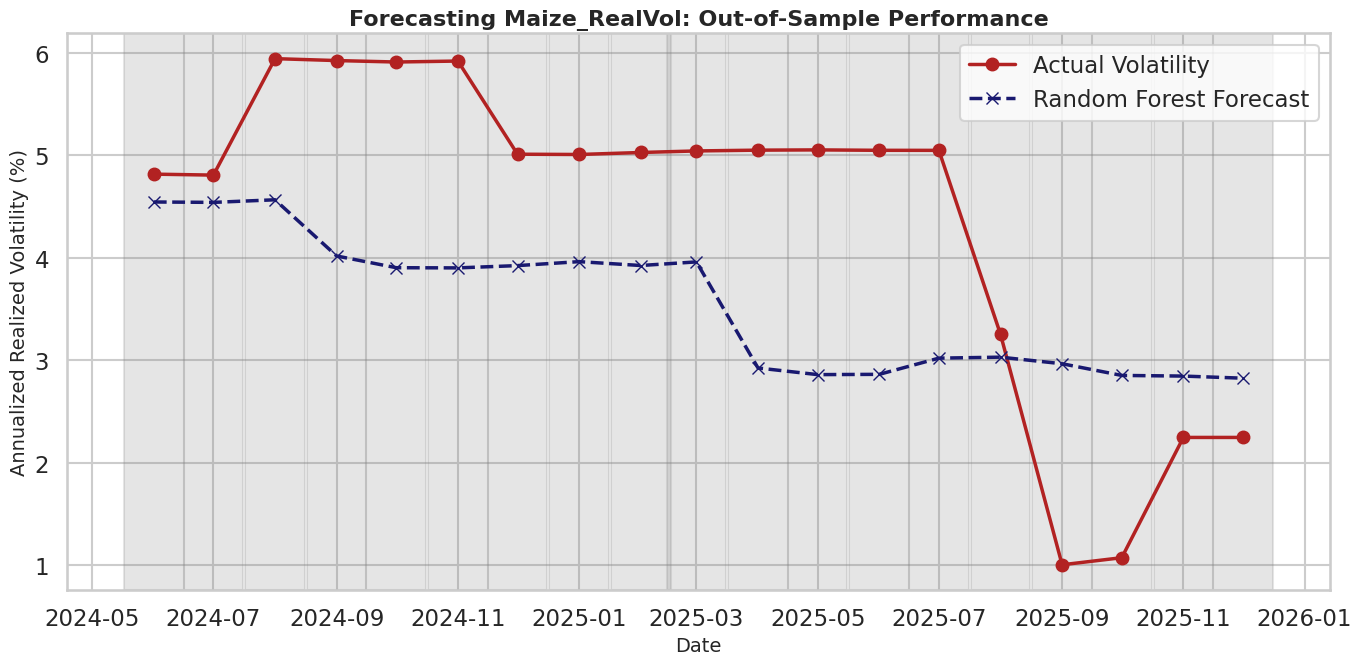

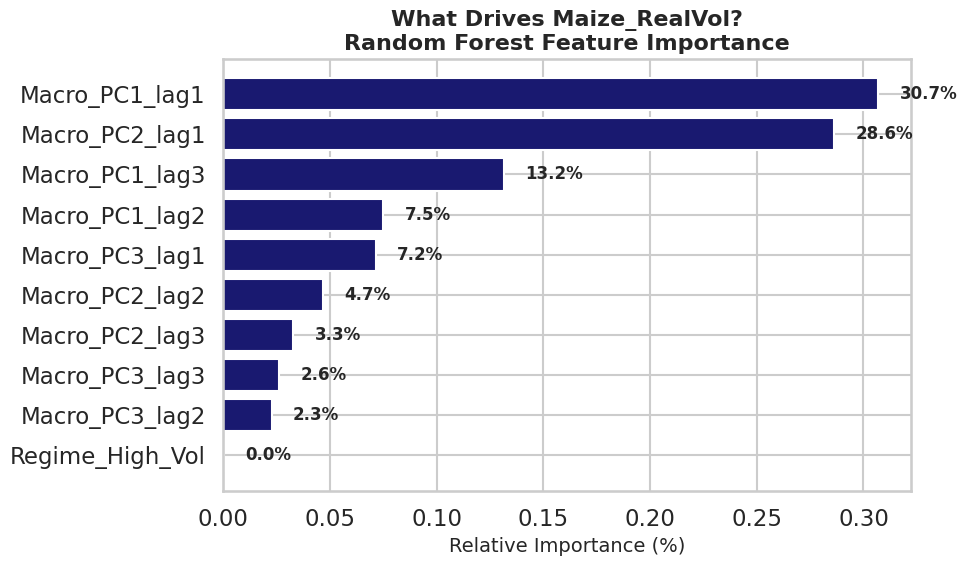

In [33]:

sns.set_theme(style="whitegrid", context="talk")


# 1. ACTUAL VS PREDICTED FORECAST TIMELINE

plt.figure(figsize=(14, 7))

# Plot Actual Testing Data
plt.plot(y_test.index, y_test.values, label='Actual Volatility', color='firebrick', marker='o', linewidth=2.5)

# Plot Model Predictions
plt.plot(y_test.index, preds_rf, label='Random Forest Forecast', color='midnightblue', linestyle='--', marker='x', linewidth=2.5)

plt.title(f'Forecasting {TARGET}: Out-of-Sample Performance', fontsize=16, fontweight='bold')
plt.ylabel('Annualized Realized Volatility (%)', fontsize=14)
plt.xlabel('Date', fontsize=14)

# Highlight High Volatility Regime Months
high_vol_dates = X_test[X_test['Regime_High_Vol'] == 1].index
for date in high_vol_dates:
    plt.axvspan(date - pd.Timedelta(days=15), date + pd.Timedelta(days=15), color='grey', alpha=0.2)

plt.legend(loc='best')
plt.tight_layout()
plt.show()


# 2. FEATURE IMPORTANCE DECODER

plt.figure(figsize=(10, 6))

# Extract feature importances
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': predictors, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=True)

# Create horizontal bar chart
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='midnightblue')

plt.title(f'What Drives {TARGET}?\nRandom Forest Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (%)', fontsize=14)

# Add percentage labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.1%}",
             ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## using random forest model

 Training Random Forest for Maize_RealVol


2026/03/13 18:10:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 18:10:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 R-Squared: 0.0356 | RMSE: 1.5303



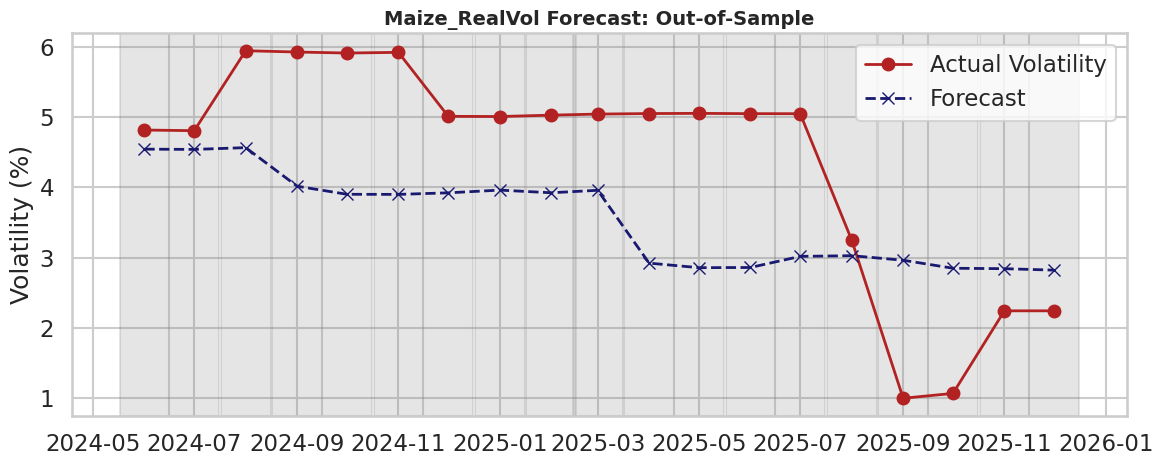

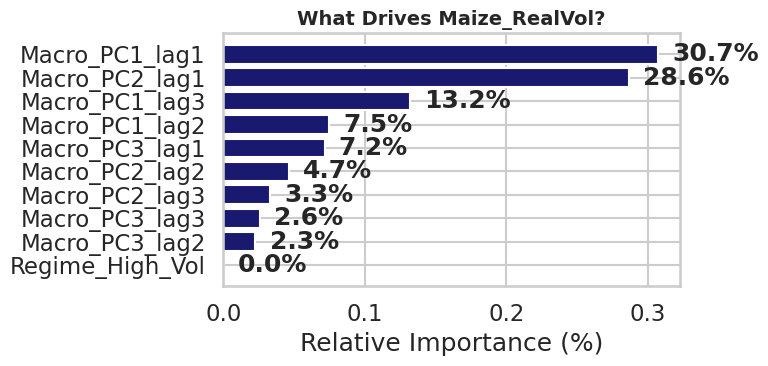



 Training Random Forest for Rice_RealVol


2026/03/13 18:10:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 18:10:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 R-Squared: -0.4313 | RMSE: 1.8233



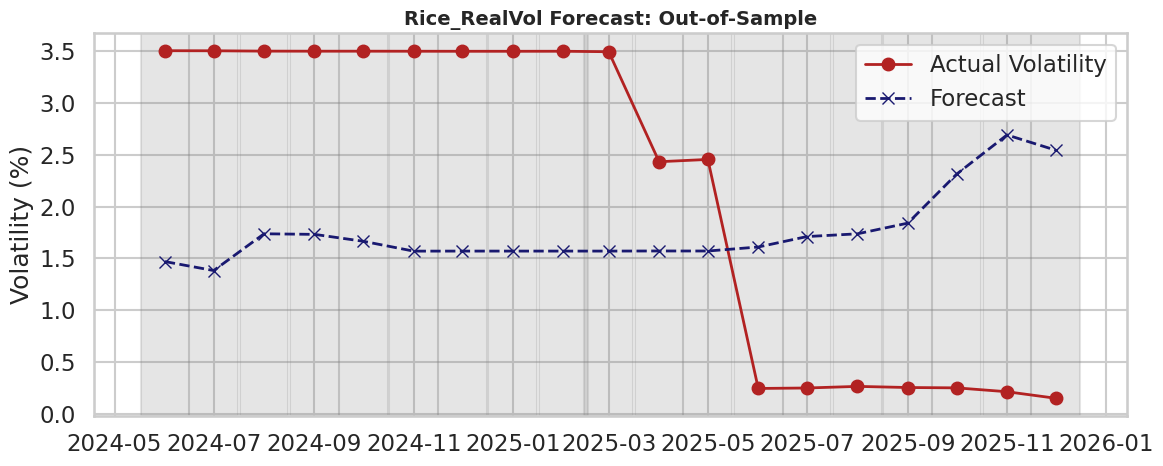

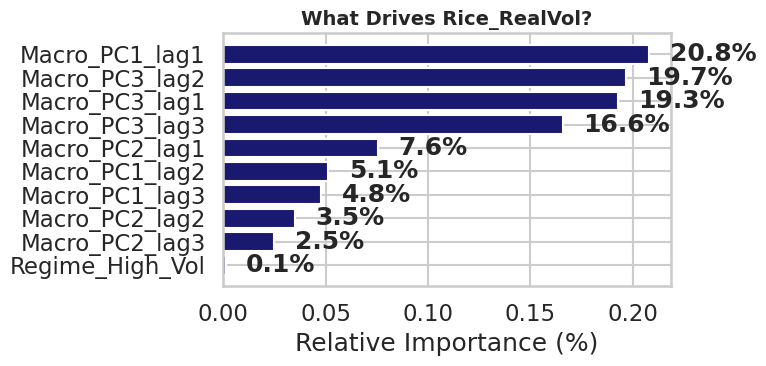



 Training Random Forest for PMS_RealVol


2026/03/13 18:10:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 18:10:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 R-Squared: -22.8502 | RMSE: 0.3988



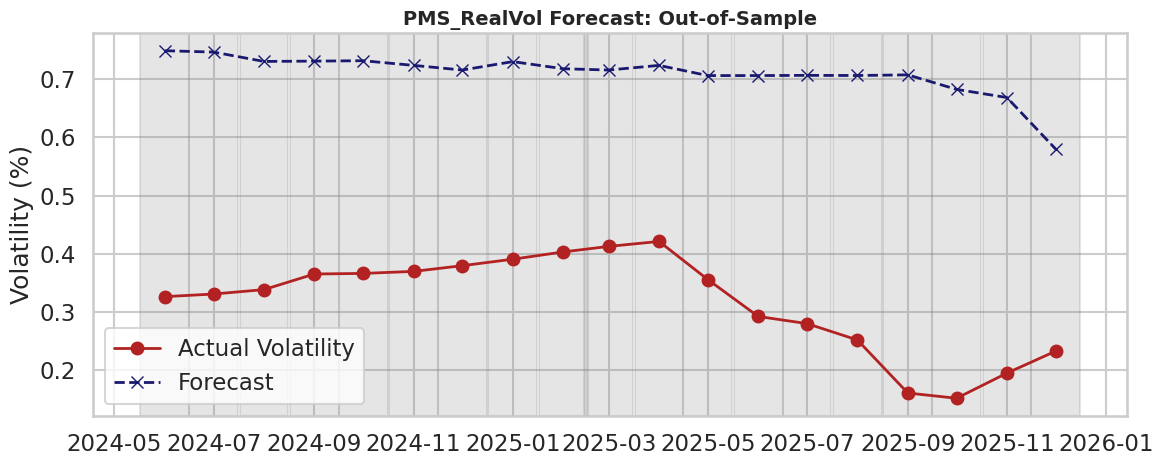

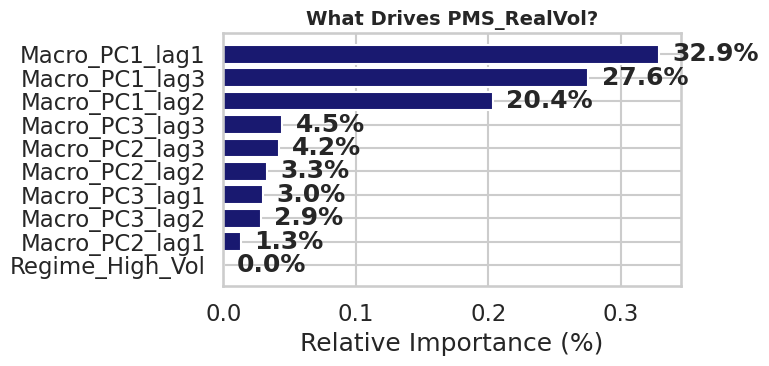



 Training Random Forest for Diesel_RealVol


2026/03/13 18:10:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 18:10:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 R-Squared: 0.6815 | RMSE: 0.0565



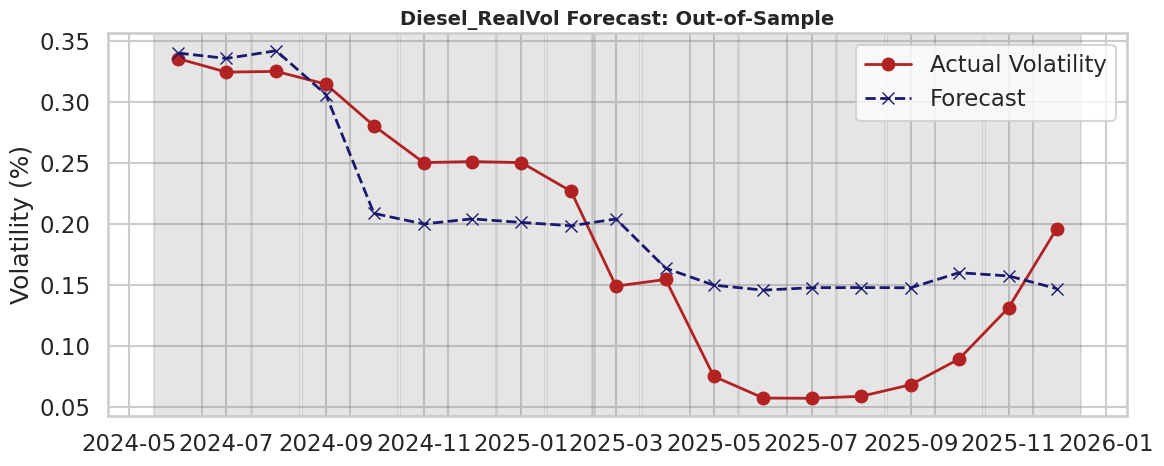

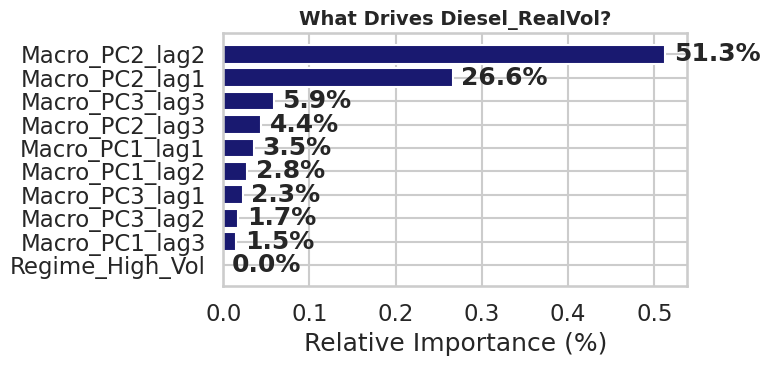

In [34]:

# 1. Define all four targets
targets = ['Maize_RealVol', 'Rice_RealVol', 'PMS_RealVol', 'Diesel_RealVol']

mlflow.set_experiment("Commodity_Volatility_Forecasting")

for TARGET in targets:
    if TARGET not in df_features.columns:
        print(f"Skipping {TARGET} - Not found in dataset.\n")
        continue

    print(f"======================================================")
    print(f" Training Random Forest for {TARGET}")

    # Define predictors
    pca_cols = [c for c in df_features.columns if 'Macro_PC' in c and '_lag' in c]
    regime_col = ['Regime_High_Vol'] if 'Regime_High_Vol' in df_features.columns else []
    predictors = pca_cols + regime_col

    # Drop NAs
    model_data = df_features.dropna(subset=[TARGET] + predictors)
    X = model_data[predictors]
    y = model_data[TARGET]

    # 80/20 Chronological Split
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Train and Track with MLflow
    with mlflow.start_run(run_name=f"RandomForest_{TARGET}"):
        rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
        rf.fit(X_train, y_train)

        preds_rf = rf.predict(X_test)

        rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
        mae_rf = mean_absolute_error(y_test, preds_rf)
        r2_rf = r2_score(y_test, preds_rf)

        mlflow.set_tag("Target_Commodity", TARGET)
        mlflow.set_tag("Model_Type", "RandomForest")
        mlflow.log_param("n_estimators", 200)
        mlflow.log_param("max_depth", 10)
        mlflow.log_metric("Test_RMSE", rmse_rf)
        mlflow.log_metric("Test_R2", r2_rf)
        mlflow.sklearn.log_model(rf, f"rf_model_{TARGET}")

    print(f" R-Squared: {r2_rf:.4f} | RMSE: {rmse_rf:.4f}\n")


    # PLOT 1: FORECAST TIMELINE

    plt.figure(figsize=(12, 5))
    plt.plot(y_test.index, y_test.values, label='Actual Volatility', color='firebrick', marker='o', linewidth=2)
    plt.plot(y_test.index, preds_rf, label='Forecast', color='midnightblue', linestyle='--', marker='x', linewidth=2)

    plt.title(f'{TARGET} Forecast: Out-of-Sample', fontsize=14, fontweight='bold')
    plt.ylabel('Volatility (%)')

    high_vol_dates = X_test[X_test['Regime_High_Vol'] == 1].index
    for date in high_vol_dates:
        plt.axvspan(date - pd.Timedelta(days=15), date + pd.Timedelta(days=15), color='grey', alpha=0.2)

    plt.legend()
    plt.tight_layout()
    plt.show()


    # PLOT 2: FEATURE IMPORTANCE

    plt.figure(figsize=(8, 4))
    importances = rf.feature_importances_
    feat_imp = pd.DataFrame({'Feature': predictors, 'Importance': importances}).sort_values(by='Importance', ascending=True)

    bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='midnightblue')
    plt.title(f'What Drives {TARGET}?', fontsize=14, fontweight='bold')
    plt.xlabel('Relative Importance (%)')

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.1%}",
                 ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
    print("\n")


## elastic net model


PLOTTING ELASTIC NET: Maize


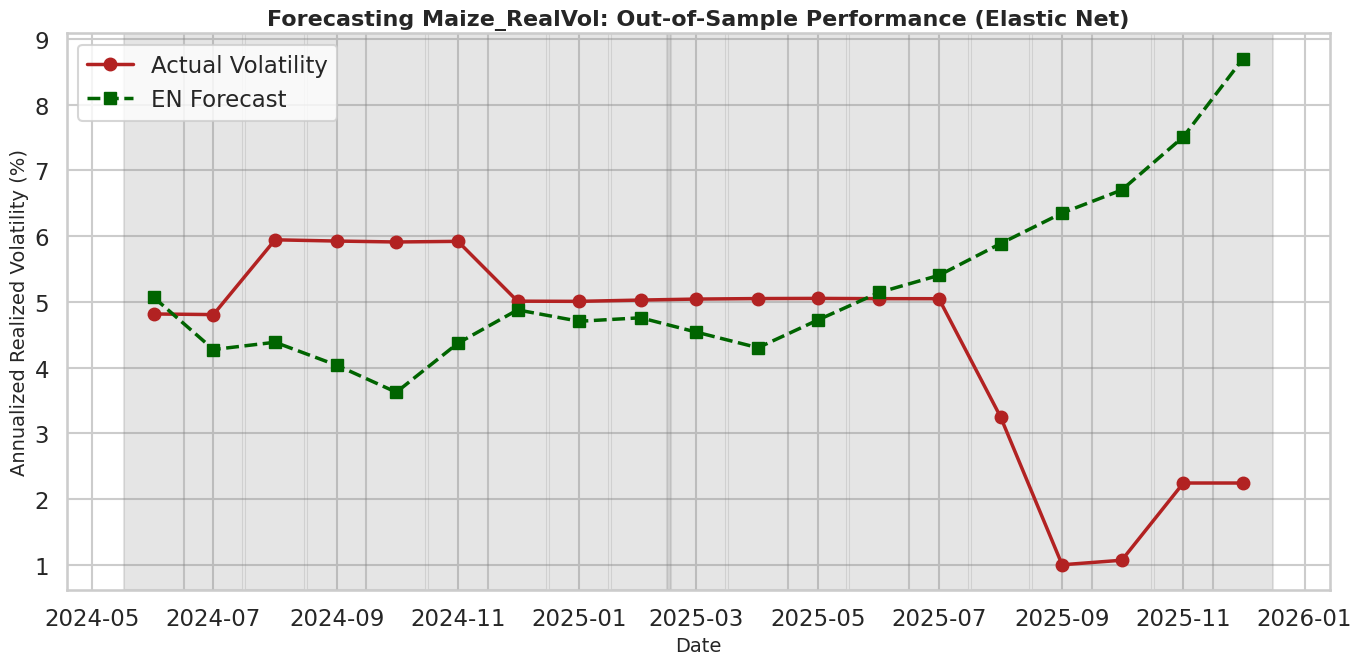

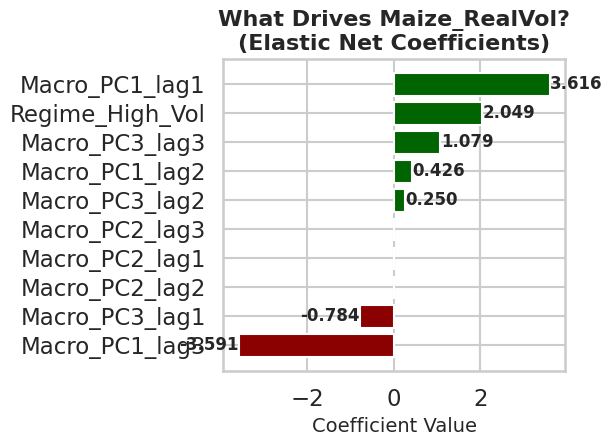




PLOTTING ELASTIC NET: Rice
No Elastic Net run found for Rice_RealVol. Skipping.


PLOTTING ELASTIC NET: PMS
No Elastic Net run found for PMS_RealVol. Skipping.


PLOTTING ELASTIC NET: Diesel
No Elastic Net run found for Diesel_RealVol. Skipping.



In [36]:

sns.set_theme(style="whitegrid", context="talk")
targets = ['Maize_RealVol', 'Rice_RealVol', 'PMS_RealVol', 'Diesel_RealVol']

experiment = mlflow.get_experiment_by_name("Commodity_Volatility_Forecasting")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

for TARGET in targets:
    if TARGET not in df_features.columns:
        continue

    print(f"\n{'='*50}")
    print(f"PLOTTING ELASTIC NET: {TARGET.replace('_RealVol', '')}")
    print(f"{'='*50}")

    # 1. Rebuild the dataset so we have X_test and y_test for this specific commodity
    pca_cols = [c for c in df_features.columns if 'Macro_PC' in c and '_lag' in c]
    regime_col = ['Regime_High_Vol'] if 'Regime_High_Vol' in df_features.columns else []
    predictors = pca_cols + regime_col

    model_data = df_features.dropna(subset=[TARGET] + predictors)
    X = model_data[predictors]
    y = model_data[TARGET]

    split_idx = int(len(X) * 0.8)
    X_test = X.iloc[split_idx:]
    y_test = y.iloc[split_idx:]

    # 2. Query MLflow for the trained Elastic Net model of this exact commodity
    commodity_runs = runs[(runs['tags.Target_Commodity'] == TARGET) & (runs['tags.Model_Type'] == 'ElasticNetCV')]

    if commodity_runs.empty:
        print(f"No Elastic Net run found for {TARGET}. Skipping.\n")
        continue

    # Get the latest run ID
    latest_run_id = commodity_runs.iloc[0]['run_id']

    # Load the trained model from MLflow
    en_model = mlflow.sklearn.load_model(f"runs:/{latest_run_id}/elastic_net_model")

    # Generate predictions
    preds_en = en_model.predict(X_test)


    # PLOT 1: FORECAST TIMELINE

    plt.figure(figsize=(14, 7))
    plt.plot(y_test.index, y_test.values, label='Actual Volatility', color='firebrick', marker='o', linewidth=2.5)
    plt.plot(y_test.index, preds_en, label='EN Forecast', color='darkgreen', linestyle='--', marker='s', linewidth=2.5)

    plt.title(f'Forecasting {TARGET}: Out-of-Sample Performance (Elastic Net)', fontsize=16, fontweight='bold')
    plt.ylabel('Annualized Realized Volatility (%)', fontsize=14)
    plt.xlabel('Date', fontsize=14)

    high_vol_dates = X_test[X_test['Regime_High_Vol'] == 1].index
    for date in high_vol_dates:
        plt.axvspan(date - pd.Timedelta(days=15), date + pd.Timedelta(days=15), color='grey', alpha=0.2)

    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


    # PLOT 2: COEFFICIENTS

    coeffs = en_model.coef_
    feat_imp = pd.DataFrame({'Feature': predictors, 'Coefficient': coeffs}).sort_values(by='Coefficient', ascending=True)

    colors = ['darkred' if c < 0 else 'darkgreen' for c in feat_imp['Coefficient']]

    bars = plt.barh(feat_imp['Feature'], feat_imp['Coefficient'], color=colors)
    plt.title(f'What Drives {TARGET}?\n(Elastic Net Coefficients)', fontsize=16, fontweight='bold')
    plt.xlabel('Coefficient Value', fontsize=14)

    for bar in bars:
        width = bar.get_width()
        if abs(width) > 0.001:
            align = 'left' if width > 0 else 'right'
            offset = 0.01 if width > 0 else -0.01
            plt.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:.3f}",
                     ha=align, va='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print("\n")


In [37]:
import mlflow
import pandas as pd

# Query MLflow to compare models
print("=========================================")
print("FINAL SCORECARD: WINNING MODELS DECLARED")
print("=========================================\n")

# Get all runs from our experiment
experiment_name = "Commodity_Volatility_Forecasting"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    print(f"Error: Could not find MLflow experiment '{experiment_name}'")
else:
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

    targets = ['Maize_RealVol', 'Rice_RealVol', 'PMS_RealVol', 'Diesel_RealVol']

    for TARGET in targets:
        # Filter runs for this specific commodity
        commodity_runs = runs[runs['tags.Target_Commodity'] == TARGET]

        if commodity_runs.empty:
            print(f"Target: {TARGET.replace('_RealVol', '')} -> No runs found in MLflow.")
            print("-" * 40)
            continue

        # Find the run with the highest Test R-Squared
        best_run_idx = commodity_runs['metrics.Test_R2'].idxmax()

        if pd.isna(best_run_idx):
             print(f"Target: {TARGET.replace('_RealVol', '')} -> Runs found, but no R2 metrics logged.")
             print("-" * 40)
             continue

        best_run = commodity_runs.loc[best_run_idx]

        best_model_type = best_run.get('tags.Model_Type', 'Unknown')
        best_r2 = best_run.get('metrics.Test_R2', np.nan)
        best_rmse = best_run.get('metrics.Test_RMSE', np.nan)

        print(f"Target: {TARGET.replace('_RealVol', '')}")
        print(f"Winner: {best_model_type}")
        print(f"Score:  R-Squared = {best_r2:.4f} | RMSE = {best_rmse:.4f}")
        print("-" * 40)


FINAL SCORECARD: WINNING MODELS DECLARED

Target: Maize
Winner: RandomForest
Score:  R-Squared = 0.0356 | RMSE = 1.5303
----------------------------------------
Target: Rice
Winner: RandomForest
Score:  R-Squared = -0.4313 | RMSE = 1.8233
----------------------------------------
Target: PMS
Winner: RandomForest
Score:  R-Squared = -22.8502 | RMSE = 0.3988
----------------------------------------
Target: Diesel
Winner: RandomForest
Score:  R-Squared = 0.6815 | RMSE = 0.0565
----------------------------------------
